# Topography and subsidence/uplift rates through time

This code uses the coordinates tracked by passive tracers to estimate the temporal evolution of topography and uplift/subsidence rates in the orogen and the back-orogen basin.

###################################################################################################################################################################################################
# By: Andres Rodriguez Corcho, Claire Mallard, Sara Polanco, Camilo Montes, Louis Moresi
# The University of Sydney 2026
# Email: andres.rodriguez1@sydney.edu.au
###################################################################################################################################################################################################

Note that for this code to work, you need to launch a jupyter notebook from within a Badlands docker container.

In [2]:
import numpy as np
import pandas as pd
import scipy.signal as signal
from matplotlib import cm
import matplotlib.mlab as ml
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib as mpl
#import badlands_companion.toolGrid as tools
#from scripts import hydroGrid as hydr
from matplotlib.ticker import FormatStrFormatter
from scipy.spatial import cKDTree
from scipy.ndimage import gaussian_filter
from skimage import graph
from skimage.graph import MCP
from io import StringIO

from scipy import ndimage
from scipy.interpolate import interp1d

#from scripts import morphoGrid as morph
from scipy.spatial import cKDTree

import matplotlib as mpl

In [3]:
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

%matplotlib

Using matplotlib backend: TkAgg


In [4]:
dataFT='./Post_processing/Produciton_post_processing_final/'
dirr='./Post_processing/Produciton_post_processing_final/slab-dip_data/'
saveDir='./Post_processing/Produciton_post_processing_final/Raw_PDFs/'

In [5]:
dicDepth={
    "0km":0,
    "2km":2,
    "4km":4
}

In [6]:
def extendArray(arrayI,NewSize):
    
    arrayF=np.array([])
    
    for i in range(0,NewSize):
        
        try:
            arrayC=arrayI[i]
            arrayF=np.append(arrayF,[arrayC])
        except IndexError:
            arrayC=np.nan
            arrayF=np.append(arrayF,[arrayC])
    return arrayF

####################################################################################################################
def getAllTracerXYZ(dataFT,Model_seed,modelDirT,root,tracers,depthIndx):
    AllTracers=[]
    Ntracers=len(tracers)
    #print(depthIndx)
    depth=dicDepth[depthIndx]
    #root=root+"{0}km_".format(str(depth))
    root=root
    
    for i in range(0,Ntracers):
        allT=[]
        
        TracerS=getPoint1Tracer_AllTimesXYZ(dataFT,Model_seed,modelDirT,root)
        
        nTimes=len(TracerS)
        
        for j in range(0,nTimes):
            #print(i,j)
            currentTracer=TracerS[j].loc[TracerS[j]["global_index"] == tracers[i]*1000]
            allT.append(currentTracer)
            
            
        AllTracers.append(allT)
        
    return AllTracers
####################################################################################################################


####################################################################################################################
def getAllTracerXYZ_var(dataFT,Model_seed,modelDirT,root,tracers,depthIndx,UwVar):
    AllTracers=[]
    Ntracers=len(tracers)
    #print(depthIndx)
    depth=dicDepth[depthIndx]
    #root=root+"{0}km_".format(str(depth))
    root=root
    
    for i in range(0,Ntracers):
        allT=[]
        
        TracerS=getPoint1Tracer_AllTimesXYZ_UwVar(dataFT,Model_seed,modelDirT,root,UwVar)
        
        nTimes=len(TracerS)
        
        for j in range(0,nTimes):
            #print(i,j)
            currentTracer=TracerS[j].loc[TracerS[j]["global_index"] == tracers[i]*1000]
            allT.append(currentTracer)
            
            
        AllTracers.append(allT)
        
    return AllTracers
####################################################################################################################

####################################################################################################################
def getPoint1Tracer_AllTimesXYZ_UwVar(dataFT,Model_seed,modelDirT,root,UwVar):
    
    tracerXYZ=[] #XY coordinates
    
    rr=0
    #df.loc['cobra':'viper', 'max_speed']
    
    #onePointTrack_oblique_HighEro_left_0.csv
    for k in range((350)):
        try:
            filename=dataFT+"/"+Model_seed+modelDirT+root+"{0}.csv".format(k)
            #print(filename)
            data = pd.read_csv(

                    filename,
                    delimiter=',',
                    #names=["Discharge","Elevation","EroDep",'EroDep failure',"EroDep hillslope","Sealevel","lake"],
                    #sep=r" ",
                    engine="c",
                    na_filter=False,
                    dtype=np.float64,
                    low_memory=False,
                )

            def_current=(data[['global_index',UwVar]])*1000
            #def_current=(data.loc[:,'ParticleId','Points:0','Points:1','Points:2'])
            #def_current=(data.loc[:,'Points:0':'Points:2','ParticleId'])
            tracerXYZ.append(def_current) 

            rr=rr+1
            #print(k)
            
            ################

        except FileNotFoundError:
            print(filename+ " not Found")
            break
            pass

    
    return tracerXYZ

####################################################################################################################

####################################################################################################################
def getPoint1Tracer_AllTimesXYZ(dataFT,Model_seed,modelDirT,root,tracer=1):
    
    tracerXYZ=[] #XY coordinates
    
    rr=0
    #df.loc['cobra':'viper', 'max_speed']
    
    #onePointTrack_oblique_HighEro_left_0.csv
    for k in range((350)):
        try:
            filename=dataFT+"/"+Model_seed+modelDirT+root+"{0}.csv".format(k)
            #print(filename)
            data = pd.read_csv(

                    filename,
                    delimiter=',',
                    #names=["Discharge","Elevation","EroDep",'EroDep failure',"EroDep hillslope","Sealevel","lake"],
                    #sep=r" ",
                    engine="c",
                    na_filter=False,
                    dtype=np.float64,
                    low_memory=False,
                )

            def_current=(data[['global_index','Points:0','Points:1','Points:2']])*1000
            #def_current=(data.loc[:,'ParticleId','Points:0','Points:1','Points:2'])
            #def_current=(data.loc[:,'Points:0':'Points:2','ParticleId'])
            tracerXYZ.append(def_current) 

            rr=rr+1
            #print(k)
            
            ################

        except FileNotFoundError:
            print(filename+ " not Found")
            break
            pass
        
        
        #tracer=3
    oneTracerTS=np.array([])
    oneTracerTS=[]

    ct=0
    
    for i in tracerXYZ:
        #print(i)
        currentData=i.iloc[tracer]
        #print(currentData)
        #oneTracerTS=np.append(oneTracerTS,[currentData])
        oneTracerTS.append(currentData)
        ct=ct+1
    
    return tracerXYZ

####################################################################################################################
###MAin function
####################################################################################################################
def getDeflectionLayers_AllTimesXYZ(dataFT,Model_seed,modelDirT,root,tracer=1):
    
    tracerXYZ=[] #XY coordinates
    
    rr=0
    #df.loc['cobra':'viper', 'max_speed']
    
    #onePointTrack_oblique_HighEro_left_0.csv
    for k in range((350)):
        try:
            filename=dataFT+"/"+Model_seed+modelDirT+root+"{0}.csv".format(k)
            #print(filename)
            data = pd.read_csv(

                    filename,
                    delimiter=',',
                    #names=["Discharge","Elevation","EroDep",'EroDep failure',"EroDep hillslope","Sealevel","lake"],
                    #sep=r" ",
                    engine="c",
                    na_filter=False,
                    dtype=np.float64,
                    low_memory=False,
                )

            def_current=(data[['global_index','Points:0','Points:1']])
            #def_current=(data.loc[:,'ParticleId','Points:0','Points:1','Points:2'])
            #def_current=(data.loc[:,'Points:0':'Points:2','ParticleId'])
            tracerXYZ.append(def_current) 

            rr=rr+1
            #print(k)
            
            ################

        except FileNotFoundError:
            print(filename+ " not Found")
            break
            pass
        
        
        #tracer=3
    oneTracerTS=np.array([])
    oneTracerTS=[]

    ct=0
    
    for i in tracerXYZ:
        #print(i)
        currentData=i.iloc[tracer]
        #print(currentData)
        #oneTracerTS=np.append(oneTracerTS,[currentData])
        oneTracerTS.append(currentData)
        ct=ct+1
    
    return tracerXYZ

def cutToInterval(Min,Max,coords):
    isY=False
    isX=False
    InterCoordsX=[]
    InterCoordsY=[]
    #print(Min,Max)
    for i in range (len(coords[0])):
        #print(i)
        aX=coords[0][i]
        aY=coords[1][i]
        #print(aX,aY)
        #print(aY<Min[1] and aY>Max[1])
        if aX>Min[0] and aX<Max[0]:
            isX=True
        if aY>Min[1] and aY<=Max[1]:
            isY=True
        else:
            isX=False
        if isX==True and isY==True:    
            InterCoordsX.append(aX)
            InterCoordsY.append(aY)
            
    return InterCoordsX, InterCoordsY

def getTracerfrom_ID(data,IDS):
    
    Xs=np.array([])
    Ys=np.array([])
    
    for i in range (len(data)):
        g_index=data.to_numpy()[:,0][i] #Global Index
        xValue=data.to_numpy()[:,1][i] #X Coordinate
        yValue=data.to_numpy()[:,2][i] #Y Coordinate
        #print(g_index)
        if any(g_index == IDS):
            
            Xs=np.append(Xs,[xValue])
            Ys=np.append(Ys,[yValue])
            #isSlopeGI=np.append(isSlopeGI,[g_index])
    
    
    return Xs,Ys

def LayerTracers_fromGlobalIDs(timeStep,layerDepth,m_ref,data,ControlSlopeDic):
    #Get global IDs of layer in the time step 0
    IDs=getSlope_ofDepth(layerDepth,m_ref,data[0],ControlSlopeDic)[2]
    
    #Get global IDs and X,Y coordinates in the requested time Step
    data_t=data[timeStep]
    X,Y=getTracerfrom_ID(data_t,IDs)
    
    return X,Y

## Tracers from global IDS

In [7]:
####################################################################################################################
def getTracer_0ID(dataFT,Model_seed,modelDirT,root,X,Y):
    
    tracerXYZ=[] #XY coordinates
    
    rr=0
    #df.loc['cobra':'viper', 'max_speed']
    
    #onePointTrack_oblique_HighEro_left_0.csv
    for k in range((5)):
        try:
            filename=dataFT+"/"+Model_seed+modelDirT+root+"{0}.csv".format(k)
            #print(filename)
            data = pd.read_csv(

                    filename,
                    delimiter=',',
                    #names=["Discharge","Elevation","EroDep",'EroDep failure',"EroDep hillslope","Sealevel","lake"],
                    #sep=r" ",
                    engine="c",
                    na_filter=False,
                    dtype=np.float64,
                    low_memory=False,
                )

            def_current=(data[['global_index','Points:0','Points:1','Points:2']])*1000
            #def_current=(data.loc[:,'ParticleId','Points:0','Points:1','Points:2'])
            #def_current=(data.loc[:,'Points:0':'Points:2','ParticleId'])
            tracerXYZ.append(def_current) 

            rr=rr+1
            #print(k)
            
            ################

        except FileNotFoundError:
            print(filename+ " not Found")
            break
            pass
        
        
        #tracer=3
    oneTracerTS=np.array([])
    oneTracerTS=[]
    from math import isclose
    
    IDS=[]
    #ct=0
    try:
        testt=len(X)>1 
        for xx,yy in zip(X,Y):
            x_=tracerXYZ[0].to_numpy()[:,1]
            y_=tracerXYZ[0].to_numpy()[:,2]
            id_=tracerXYZ[0].to_numpy()[:,0]
            
            #print(xx)
            #print(yy)
            try:
                isCord=np.where(np.logical_and(x_ == xx, y_==yy))[0][0]
            except IndexError:
                isCord=np.where(np.logical_and(x_ == xx, y_==yy))[0]
            
            IDS.append(id_[isCord])
        IDS=np.array(IDS)
    except TypeError:
    #print(i)

        IDS=None
        x_=tracerXYZ[0].to_numpy()[:,1]
        y_=tracerXYZ[0].to_numpy()[:,3]
        id_=tracerXYZ[0].to_numpy()[:,0]
        
        #print(x_,y_)

        isCord=np.where(np.logical_and(x_ == X, y_==Y))[0][0]
        IDS=id_[isCord]
    
    #return x_,y_,id_
    #return x_[isCord],y_[isCord],id_[isCord]
    return IDS

## Getting tracers elevations

In [8]:
def getElevation_alltimes_OP(dataFT,model,tracers_s,depthIndx="0km"):
    depthIndx="0km"
    
    root_S=["tracersP_"]
    name_SS=["Arc-Collision_Bdls"]
    modelDirT_s=["/Tectonic_subsidence-uplift/"]
    
    Basin_s=getAllTracerXYZ(dataFT,model,modelDirT_s[0],root_S[0],tracers_s,depthIndx)
    
    Zs_All_tracers=[]
    Xs_All_tracers=[]
    
    for i in range(0,len(Basin_s)):
        ctracer=Basin_s[i]
        Zs_tracers=np.array([])
        Xs_tracers=np.array([])
        #print(ctracer[i])
        for j in range(0,len(ctracer)):
            z=ctracer[j].drop(["Points:0","Points:2","global_index"],1)
            x=ctracer[j].drop(["Points:1","Points:2","global_index"],1)
    #         z=ctracer[j].drop("Points:1",1)
    #         z=ctracer[j].drop("ParticleId",1)
            #Zs_tracers.append(z)
            #print(z)
            Zs_tracers=np.append(Zs_tracers,z)
            Xs_tracers=np.append(Xs_tracers,x)
            
        Zs_All_tracers.append(Zs_tracers)
        Xs_All_tracers.append(Xs_tracers)
    
    return Zs_All_tracers,Xs_All_tracers

def getElevation_alltimes_arc(dataFT,model,tracers_s,depthIndx="0km"):
    depthIndx="0km"
    
    root_S=["arc_disp_"]
    name_SS=["Arc-Collision_Bdls"]
    modelDirT_s=["/Tectonic_subsidence-uplift/"]
    
    Basin_s=getAllTracerXYZ(dataFT,model,modelDirT_s[0],root_S[0],tracers_s,depthIndx)
    
    Zs_All_tracers=[]
    Xs_All_tracers=[]
    
    for i in range(0,len(Basin_s)):
        ctracer=Basin_s[i]
        Zs_tracers=np.array([])
        Xs_tracers=np.array([])
        #print(ctracer[i])
        for j in range(0,len(ctracer)):
            z=ctracer[j].drop(["Points:0","Points:2","global_index"],1)
            x=ctracer[j].drop(["Points:1","Points:2","global_index"],1)
    #         z=ctracer[j].drop("Points:1",1)
    #         z=ctracer[j].drop("ParticleId",1)
            #Zs_tracers.append(z)
            #print(z)
            Zs_tracers=np.append(Zs_tracers,z)
            Xs_tracers=np.append(Xs_tracers,x)
            
        Zs_All_tracers.append(Zs_tracers)
        Xs_All_tracers.append(Xs_tracers)
    
    return Zs_All_tracers,Xs_All_tracers

## Ero-Depo Average values

In [14]:
## Functions
from scipy.interpolate import interp1d
def getEroDepoLayers_AllTimesXYZ2(dataFT,Model_seed,modelDirT,root,tracer=1):
    
    tracerXYZ=[] #XY coordinates
    
    rr=0
    #df.loc['cobra':'viper', 'max_speed']
    
    #onePointTrack_oblique_HighEro_left_0.csv
    for k in range((1000)):
        try:
            filename=dataFT+"/"+Model_seed+modelDirT+root+"{0}.csv".format(k)
            #print(filename,root)
            data = pd.read_csv(

                    filename,
                    delimiter=',',
                    #names=["Discharge","Elevation","EroDep",'EroDep failure',"EroDep hillslope","Sealevel","lake"],
                    #sep=r" ",
                    engine="c",
                    na_filter=False,
                    dtype=np.float64,
                    low_memory=False,
                )

            def_current=(data[['EroDep','Points:0','Points:2','Elevation']])
            #def_current=(data.loc[:,'ParticleId','Points:0','Points:1','Points:2'])
            #def_current=(data.loc[:,'Points:0':'Points:2','ParticleId'])
            tracerXYZ.append(def_current) 

            rr=rr+1
            #print(k)
            
            ################

        except FileNotFoundError:
            print(filename+ " not Found")
            break
            pass
        
        
        #tracer=3
    oneTracerTS=np.array([])
    oneTracerTS=[]

    ct=0
    
#     for i in tracerXYZ:
#         #print(i)
#         currentData=i.iloc[tracer]
#         #print(currentData)
#         #oneTracerTS=np.append(oneTracerTS,[currentData])
#         oneTracerTS.append(currentData)
#         ct=ct+1
    
    return tracerXYZ

from scipy.spatial import cKDTree

def getEroDepo_aboveTracer(dataFT,Model_seed,Xs_all_times):
    
    
    #Xs_all_times=getElevation_alltimes_OP()[1]
    
    c=getEroDepoLayers_AllTimesXYZ2(dataFT,Model_seed,"/EroDepo_Evolution_/","eroD_evo_")
    
    
    XY_0=np.copy(c[0].to_numpy()[:,1]),np.copy(c[0].to_numpy()[:,2]) #2D-np.array with XY coordinates of points in time 0
    eroDe_0=np.copy(c[0].to_numpy()[:,0]) #Ero depo in time step 0
    elevation_0=np.copy(c[0].to_numpy()[:,3]) #elevation
    #X=density array that will be used for all time steps
    X0=np.copy(c[0].to_numpy()[:,1])
    
    
#     eroDE_F = []
#     elev_F = []
    
    eroT = []
    elevT = []
    
    for k in range(0,len(c)):
        #Get data from the current time step
        #XY_=c[k].to_numpy()[:,1:3]
        X_=c[k].to_numpy()[:,1:3][:,0]
        eroDe_=c[k].to_numpy()[:,0]
        elev_=c[k].to_numpy()[:,3]
        #Interpolate to match the size of grid sub-0
        #eroDE_F.append(griddata(XY_, eroDe_, (XY_0), method='linear'))
        
        #Interpolation of the current step
        f=interp1d(X_,eroDe_)
        f_elev=interp1d(X_,elev_)
        
        #Using interpolation fn with Xs of 0 step
#         eroDE_F.append(f(X0))
#         elev_F.append(f_elev(X0))
        #print(Xs_all_times)
    
        x_tracer=Xs_all_times[k]
        eroT.append(f(x_tracer))
        elevT.append(f_elev(x_tracer))
        #Uplift/Subsidence rate
        #print(f_elev(X0[basinCut]).shape)
#         dispVrate.append(np.gradient(f_elev(X0[basinCut]), #The elevation
#                                     t, # The time variable
#                                     ))
    ########################## THe timestep -1 is the instantaneous one
    ct=0
    oldED=eroT[0]
    inst_ED=[]

    for i in range(1, len(eroT)):
        #print(i)
        CurrentED=np.copy(eroT[i])
        diff=CurrentED-oldED
        inst_ED.append(diff)
        oldED=CurrentED
        
        
    return eroT, inst_ED,elevT

In [22]:
from scipy import interpolate

#get_avgs_Ero_DepoFN
def get_avgs_Ero_Depo(dataFT,Model_seed,modelDirT_s,root_S,Area,AxisX=None,AxisXO=None,leftF=None,leftFO=None,rightFO=None):

    #dataFT=dataFT+Model_seed
    #Dataframe with passive tracers data (subducting plate) in all time steps
    c=getEroDepoLayers_AllTimesXYZ2(dataFT,Model_seed,modelDirT_s,root_S)

    #print(root_S)
    #Because the TIN mesh nodes change in time, we need to interpolate data to the initial grid in order to 
    #be able to compare different time steps
    XY_0=(c[0].to_numpy()[:,1],c[0].to_numpy()[:,2]) #2D-np.array with XY coordinates of points in time 0
    eroDe_0=c[0].to_numpy()[:,0] #Ero depo in time step 0
    #X=density array that will be used for all time steps
    X0=c[0].to_numpy()[:,1]
    #Cut to X interval Bdls cross-section data
    #basinCut=np.where(np.logical_and(X0[:]>=-300.*1e3,X0[:]<=700.*1e3))[0]
    basinCut=Area
    #List with interpolated eroDE_F per time step
    eroDE_F = []
    #List with interpolated elevations per time step
    elevDE_F = []
    
    ########################################################################################
    ### FILTERS FOR AREAS
    ########################################################################################
    GenCut=np.where(np.logical_and(X0[:]>=-300.*1e3,X0[:]<=700.*1e3))[0]
    basinCut=np.where(np.logical_and(X0[:]>=100.*1e3,X0[:]<=700.*1e3))[0]
    prisCut=np.where(np.logical_and(X0[:]>=-300.*1e3,X0[:]<=100.*1e3))[0]
    ########################################################################################
   # if AxisX is not None:

    ########################################################################################
    
    if Area=="Gen":
        basinCut=GenCut
    elif Area=="Basin":
        basinCut=basinCut
    elif Area=="Prism":
        basinCut=prisCut
    
    for k in range(0,len(c)-1):
    #for k in range(0,200):
        #print(leftF is None)
        #Get data from the current time step
        #XY_=c[k].to_numpy()[:,1:3]
        
        #Interpolate to match the size of grid sub-0
        #eroDE_F.append(griddata(XY_, eroDe_, (XY_0), method='linear'))
        
        #### Interpolating the erosion-deposition
        #X_=c[k].to_numpy()[:,1:3][:,0]
        X_=c[k].to_numpy()[:,1]
        eroDe_=c[k].to_numpy()[:,0]
        f=interpolate.interp1d(X_,eroDe_)
        
        #### Interpolating elevation
        elev_=c[k].to_numpy()[:,2]
        f_evel=interpolate.interp1d(X_,elev_)
        
        if AxisX is None and AxisXO is None:
            eroDE_F.append(f(X0[basinCut]))
            elevDE_F.append(f(X0[basinCut]))
        elif AxisXO is None and AxisX is not None:
#             basinL_cut=np.where(np.logical_and(X0[:]>=100.*1e3,X0[:]<=375e3))[0]
#             basinR_cut=np.where(np.logical_and(X0[:]>=375.*1e3,X0[:]<=700e3))[0]
            if leftF is None:
                Llim=50e3
            else:
                #print(k,len(c))
                Llim=leftF[k]
            #print("fuck again")
            #print(np.shape(Llim),np.shape(AxisX))
#             try:
            #print(Llim)
#             except IndexError: 
#                 print(Llim)
               # pass
            #print(k)
            basinL_cut=np.where(np.logical_and(X0[:]>=Llim,X0[:]<=AxisX[k]))[0] #like this one
            basinR_cut=np.where(np.logical_and(X0[:]>=AxisX[k],X0[:]<=700e3))[0]  #like this one
        
#             basinL_cut=np.where(np.logical_and(X0[:]>=-50.*1e3,X0[:]<=AxisX[k]))[0]
#             basinR_cut=np.where(np.logical_and(X0[:]>=AxisX[k],X0[:]<=800e3))[0]
            
            #eroDE_F.append(f(X0[basinCut]))
            
#         if AxisXO is None and AxisX is None:     
#             eroDE_F.append(f(X0[basinCut]))
#             elevDE_F.append(f(X0[basinCut]))
            
        if AxisX is None and  AxisXO is not None:
            if leftFO is None or rightFO is None:
                LlimL=-300e3
                LlimR=50e3
            else:
                LlimL=leftFO[k]
                LlimR=rightFO[k]
            
            orogenL_cut=np.where(np.logical_and(X0[:]>=LlimL,X0[:]<=AxisXO[k]))[0]
            
            
            orogenR_cut=np.where(np.logical_and(X0[:]>=AxisXO[k],X0[:]<=LlimR))[0]
            

            
        if Area=="BasinL":
            basinCut=basinL_cut
            eroDE_F.append(f(X0[basinCut]))
            elevDE_F.append(f(X0[basinCut]))
        elif Area=="BasinR":
            basinCut=basinR_cut
            eroDE_F.append(f(X0[basinCut]))
            elevDE_F.append(f(X0[basinCut]))
        elif Area=="orogenL":
            basinCut=orogenL_cut
            eroDE_F.append(f(X0[basinCut]))
            elevDE_F.append(f(X0[basinCut]))
        elif Area=="orogenR":
            basinCut=orogenR_cut
            eroDE_F.append(f(X0[basinCut]))
            elevDE_F.append(f(X0[basinCut]))
            
        

    ########################## THe timestep -1 is the instantaneous one
#     ct=0
#     oldED=eroDE_F[0]
#     inst_ED=[]

#     for i in range(1, len(eroDE_F)):
#         #print(i)
#         CurrentED=np.copy(eroDE_F[i])
#         print(CurrentED.shape,oldED.shape)
#         diff=CurrentED-oldED
#         inst_ED.append(diff)
#         oldED=CurrentED

    ########## The average of the selected area is calculated in every time step 
#     avg_insDepo = []
#     avg_insEro = []
    avg_CumDepo = []
    avg_CumEro = []
    avg_Elev = []

    #t=np.linspace(0,32.55,162)

    for i in range(1, len(eroDE_F)):
        #print(i)
        ### Just Depo
        #Inst
        try:
#             InstDepo=np.copy(inst_ED[i-1])
#             InstDepo[InstDepo < 0] = np.nan
            #Cumulated
            CumuDepo=np.copy(eroDE_F[i])
            CumuDepo[CumuDepo < 0] = np.nan
            elev_a=np.copy(elevDE_F[i])
            elev_a[elev_a > 0] = np.nan

            ### Just Erosion
            #Inst
#             InstEro=np.copy(inst_ED[i])
#             InstEro[InstEro > 0] = np.nan
            #Cumulated
            CumuEro=np.copy(eroDE_F[i])
            CumuEro[CumuEro > 0] = np.nan
        except IndexError:
            pass
            break
        
        
        #iMax,iMins= get_maxs_or_mins(data,threshold)
        #Add to lists
#         avg_insDepo.append(np.nanmean(InstDepo))
#         avg_insEro.append(np.nanmean(InstEro))
        #avg_CumDepo.append(np.nanmean(CumuDepo[CumuDepo>200e3]))
        #avg_CumEro.append(np.nanmean(CumuEro[CumuEro<200e3]))
        avg_CumDepo.append(np.nanmean(CumuDepo))
        avg_CumEro.append(np.nanmean(CumuEro))
        avg_Elev.append(np.nanmean(elev_a))

    return avg_CumDepo,avg_CumEro,avg_Elev#,avg_insDepo,avg_insEro

def calc_cumuTecV(data):
    n=len(data)
    
    f_data=np.array([])
    
    cumu=0
    for i in range(0,len(data)):
        if ct==0:
            cumu=cumu+data[0]
            f_data=np.append(f_data,[cumu])
            
        else:
            cumu=cumu+data[i]
                       
            f_data=np.append(f_data,[cumu])
        
        #ct=ct+1
    return f_data

def getElevation_alltimes_orogen(dataFT,model,tracers_s,depthIndx="0km"):
    depthIndx="0km"
    
    #root_S=["tracersP_"]
    #name_SS=["Arc-Collision_Bdls"]
    modelDirT_s=["/Tectonic_subsidence-uplift/"]
    root_S=["arc_disp_"]
    #name_SS="Tectonic subsidence/uplift arc"

    
    Basin_s=getAllTracerXYZ(dataFT,model,modelDirT_s[0],root_S[0],tracers_s,depthIndx)
    
    Zs_All_tracers=[]
    Xs_All_tracers=[]
    
    for i in range(0,len(Basin_s)):
        ctracer=Basin_s[i]
        Zs_tracers=np.array([])
        Xs_tracers=np.array([])
        #print(ctracer[i])
        for j in range(0,len(ctracer)):
            z=ctracer[j].drop(["Points:0","Points:2","global_index"],1)
            x=ctracer[j].drop(["Points:1","Points:2","global_index"],1)
    #         z=ctracer[j].drop("Points:1",1)
    #         z=ctracer[j].drop("ParticleId",1)
            #Zs_tracers.append(z)
            #print(z)
            Zs_tracers=np.append(Zs_tracers,z)
            Xs_tracers=np.append(Xs_tracers,x)
            
        Zs_All_tracers.append(Zs_tracers)
        Xs_All_tracers.append(Xs_tracers)
    
    return Zs_All_tracers,Xs_All_tracers

### Values for Paper description

1. #### Arc

Elevation _ 50.6 (very low Ero)  to 3369.70 (HighEro) - 34 Myr

Uplift.  _ 7.97 (NoEro) to 309.50 (HighEro) - 23 Myr

2. #### Basin

Elevation _ -212.61 (NoEro) to -3479 (HighEro) - 34 Myr

Subsidence _  -58.73 (NoEro) to -338.43 (HighEro) - 19 Myr

HighEro
./Post_processing/Produciton_post_processing_final//HighEro/Tectonic_subsidence-uplift/tracersP_204.csv not Found
./Post_processing/Produciton_post_processing_final//HighEro/Tectonic_subsidence-uplift/tracersP_204.csv not Found
./Post_processing/Produciton_post_processing_final//HighEro/Tectonic_subsidence-uplift/arc_disp_204.csv not Found
./Post_processing/Produciton_post_processing_final//HighEro/Tectonic_subsidence-uplift/arc_disp_204.csv not Found
./Post_processing/Produciton_post_processing_final//HighEro/Tectonic_subsidence-uplift/arc_disp_204.csv not Found
./Post_processing/Produciton_post_processing_final//HighEro/Tectonic_subsidence-uplift/arc_disp_204.csv not Found
./Post_processing/Produciton_post_processing_final//HighEro/Tectonic_subsidence-uplift/arc_disp_204.csv not Found
./Post_processing/Produciton_post_processing_final//HighEro/EroDepo_Evolution_/eroD_evo_201.csv not Found


/usr/local/lib/python3.5/dist-packages/ipykernel_launcher.py:180: RuntimeWarning: Mean of empty slice
/usr/local/lib/python3.5/dist-packages/ipykernel_launcher.py:181: RuntimeWarning: Mean of empty slice
/usr/local/lib/python3.5/dist-packages/ipykernel_launcher.py:182: RuntimeWarning: Mean of empty slice


./Post_processing/Produciton_post_processing_final//HighEro/EroDepo_Evolution_/eroD_evo_201.csv not Found
./Post_processing/Produciton_post_processing_final//HighEro/EroDepo_Evolution_/eroD_evo_201.csv not Found
./Post_processing/Produciton_post_processing_final//HighEro/EroDepo_Evolution_/eroD_evo_201.csv not Found
(199,) (204,)
204 204
one plot - arc
Elevation 23 3369.7058064056523 Subsidence 23 309.50104713761357
one plot - basin
Elevation 34 -3479.725325332116 Subsidence 17 -338.4322263338481 subsidence 24 -196.42979146092512
MedEro
./Post_processing/Produciton_post_processing_final//MedEro/Tectonic_subsidence-uplift/tracersP_202.csv not Found
./Post_processing/Produciton_post_processing_final//MedEro/Tectonic_subsidence-uplift/tracersP_202.csv not Found
./Post_processing/Produciton_post_processing_final//MedEro/Tectonic_subsidence-uplift/arc_disp_202.csv not Found
./Post_processing/Produciton_post_processing_final//MedEro/Tectonic_subsidence-uplift/arc_disp_202.csv not Found
./Pos

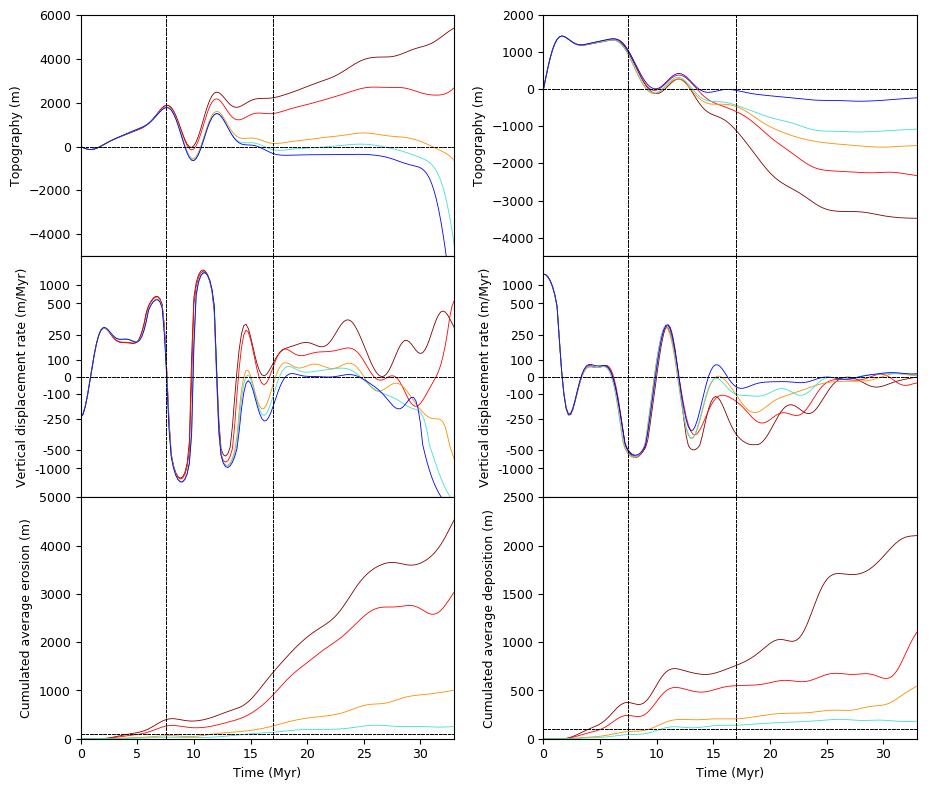

In [84]:
Models_ls=["HighEro","MedEro","LowEro2","LowEro3","NoEro"]
#colours=["red","darkmagenta","magenta","blue"]
colours=["maroon","red","darkorange","turquoise","blue"]

#this iterates the other models.. later on
xLimit=[0,33]
tracerss=["Left Shoulder","Right Shoulder"]
sDip_s=["80 km depth","300 km depth"]
#colours=["red","blue","green","cyan","goldenrod"]
#colours=["red","blue","magenta","black","gray"]
#colours=["red","blue","black","gray"]

markers=["o","^","v"]

break_ups1=[7.5,17]

####################### Basin case ####
ylimits=[-4500,2000]
#yelLimits=[-20000,11000] #Before camilo meeting
yelLimits=[-3000,3000]
#DepLimits=[0,3000]
DepLimits=[0,2500]

y_ll=[yelLimits,ylimits]

#######################

####################### orogen case ###
ylimits=[-5000,6000]
#yelLimits=[-60000,45000]
yelLimits=[-3000,3000]
#eroLi=[0,6000]
eroLi=[0,5000]

y_ll2=[yelLimits,ylimits]
#######################

t_step=0.20

#t=np.linspace(0,32.55,161)

tec_events=break_ups1

fig = plt.figure(figsize=(14,10))
################################## MAIN LOOP
ct=0


for model in Models_ls:
    print(model)
    # Second, apply the filter
    N  = 5  # Filter order
    Wn = 0.028 # Cutoff frequency
    #n = 0.03 # Cutoff frequency
    B, A = signal.butter(N, Wn, output='ba',fs=0.45,btype="lowpass")
    
    ## GET TRACERS GLBOAL IDS
#     left_ids=getTracer_0ID(dataFT,model,"/Tectonic_subsidence-uplift/","tracersP_",
#                         [leftShoulderCoord1[0],leftShoulderCoord3[0]],
#                         [leftShoulderCoord1[1],leftShoulderCoord3[1]],
#                        )

#     right_ids=getTracer_0ID(dataFT,model,"/Tectonic_subsidence-uplift/","tracersP_",
#                         [rightShoulderCoord1[0],rightShoulderCoord3[0]],
#                         [rightShoulderCoord1[1],rightShoulderCoord3[1]],
#                       )
    
    
    ####BASIN
    left_ids_b=getTracer_0ID(dataFT,model,"/Tectonic_subsidence-uplift/","tracersP_", #left in normal
                        [leftShoulderCoord1[0]],
                        [leftShoulderCoord1[1]],
                       )
    
    Axis_ids=getTracer_0ID(dataFT,model,"/Tectonic_subsidence-uplift/","tracersP_",
                    [AxisCoord1[0]],
                    [AxisCoord1[1]],
                   )
    ####OROGEN
    
    
    Axis_ids_arc=getTracer_0ID(dataFT,model,"/Tectonic_subsidence-uplift/","arc_disp_",
                        [rightFlankCoord1_arc[0]],
                        [rightFlankCoord1_arc[1]],
                       )
    

    right_ids_arc=getTracer_0ID(dataFT,model,"/Tectonic_subsidence-uplift/","arc_disp_",
                        [rightFlankCoord1[0]],
                        [rightFlankCoord1[1]],
                       )
    
    l_idO=getTracer_0ID(dataFT,model,"/Tectonic_subsidence-uplift/","arc_disp_",
                        [leftOro_Coord1[0]],
                        [leftOro_Coord1[1]],
                       )
    
    r_idO=getTracer_0ID(dataFT,model,"/Tectonic_subsidence-uplift/","arc_disp_",
                        [RightOro_Coord1[0]],
                        [RightOro_Coord1[1]],
                       )
    
    ############################################################################
    #TRACERS FOR TOPOGRAPHY AND SUBSIDENCE PLOTS
    
    ## Basin
    ##### LEFT SHOULDER Tracers
    l_tracers_b=getElevation_alltimes_OP(dataFT,model,(left_ids_b)/1000)[0]
    
    ##### RIGHT SHOULDER Tracers
    #r_tracers_b=getElevation_alltimes_OP(dataFT,model,(right_ids)/1000)[0
                                                                      
                                                                                        
    Axis_tracers_b=getElevation_alltimes_OP(dataFT,model,(Axis_ids)/1000)[1]
                                                                      
    ## Orogen
                                                                        
    l_tracers_arc=getElevation_alltimes_orogen(dataFT,model,(right_ids_arc)/1000)[0]
    ##### RIGHT SHOULDER Tracers
    #r_tracers_arc=getElevation_alltimes_orogen(dataFT,model,(right_ids)/1000)[0]   
                                                                      
    Axis_tracers_arc=getElevation_alltimes_orogen(dataFT,model,(Axis_ids_arc)/1000)[1]
    
    ############################################################################ 
                                                                      
    ############################################################################                                                                  
    ## AVERAGE ERO-DEPO TRACERS BASIN AND OROGEN
                                                                      
    ## THIS ONE IS FOR THE AVERAGE DEPO OF THE BASIN (LEFT LIMIT)                                                                  
    ### x- coordinate for left boundary of the basin
    leftF_tracers=getElevation_alltimes_arc(dataFT,model,(Axis_ids_arc)/1000)[1]
                       
                                                                      
    ## THESE TWO ARE FOR THE AVERAGE ERO OF THE OROGEN
    #### Left boundary orogen
    l_tracersB=getElevation_alltimes_orogen(dataFT,model,(l_idO)/1000)[0]
    ### Right boundary orogen
    r_tracersB=getElevation_alltimes_orogen(dataFT,model,(r_idO)/1000)[0]                                                                  
                                                                      
    
    ############################################################################ 
    
    ###
    #lTra=getEroDepo_aboveTracer(dataFT,model,l_tracers[0])[0]
    #rTra=getEroDepo_aboveTracer(dataFT,model,r_tracers[0])[0]
    
    ###############################################################################
    ## AXIS CASE BASIN
    
    EDL_e=get_avgs_Ero_Depo(dataFT,model,"/EroDepo_Evolution_/","eroD_evo_","BasinL",
                            AxisX=Axis_tracers[0],leftF=leftF_tracers[0])
    
    depoL= EDL_e[0]
    eroL=  EDL_e[1]
    elevL= EDL_e[2]
    
    
    EDR_e= get_avgs_Ero_Depo(dataFT,model,"/EroDepo_Evolution_/","eroD_evo_","BasinR",AxisX=Axis_tracers[0])
    
    depoR= EDR_e[0]
    eroR=  EDR_e[1]
    elevR= EDR_e[2]
    
    depoR = signal.filtfilt(B,A,depoR)
    eroR = signal.filtfilt(B,A,eroR)
    elevR = signal.filtfilt(B,A,elevR)
    
    depoL = signal.filtfilt(B,A,depoL)
    eroL = signal.filtfilt(B,A,eroL)
    elevL = signal.filtfilt(B,A,elevL)
    
    #################################################################################
    
    ###############################################################################
    ## AXIS CASE OROGEN
    
#     depoL=get_avgs_Ero_Depo(dataFT,model,"/EroDepo_Evolution_/","eroD_evo_","orogenL",None,
#                             AxisXO=Axis_tracers[0])[0]
    eroL=get_avgs_Ero_Depo(dataFT,model,"/EroDepo_Evolution_/","eroD_evo_","orogenL",None,
                           AxisXO=Axis_tracers[0],)[1]
    
    
#     depoR=get_avgs_Ero_Depo(dataFT,model,"/EroDepo_Evolution_/","eroD_evo_","orogenR",None,
#                             AxisXO=Axis_tracers[0])[0]
    eroR=get_avgs_Ero_Depo(dataFT,model,"/EroDepo_Evolution_/","eroD_evo_","orogenR",None,
                           AxisXO=Axis_tracers[0],)[1]
    
#     depoL=signal.filtfilt(B,A,depoL)
    eroL=signal.filtfilt(B,A,eroL)
    
#     depoR=signal.filtfilt(B,A,depoR)
    eroR=signal.filtfilt(B,A,eroR)
    
    ###############################################################################
    ## FINAL VARIABLES
    l_tracers=l_tracers_arc
    r_tracers=l_tracers_b
    
    ###############################################################################
    
    for k in range(0,len(l_tracers)):
    #for k in range(0,1):
        #tracerInx=dicTracer_S[tracerss[k]]
        #print(tracerInx)
        
        ######## 0km
        #rift_Z1=np.array(l_tracers[k])
        
        try:
            rift_Z1=np.array(l_tracers[k])
            rift_Z2=np.array(r_tracers[k])
            
            #t=np.linspace(0,len(l_tracers[k])*t_step,len(l_tracers[k]))
            t=np.arange(0,len(l_tracers[k])*t_step,t_step)
        except IndexError: 
            #t=np.linspace(0,len(l_tracers[0])*t_step,len(l_tracers[0]))
            t=np.arange(0,len(l_tracers[0])*t_step,t_step)
            
            rift_Z1=np.array(l_tracers)
            rift_Z2=np.array(r_tracers)
        #rift_Z1=extendArray(rift_Z1,len(t))
        
        
        #print(rift_Z1)
        #break
        ## ADD TO BIG ARRAY TO SAVE
        ToposL.append(rift_Z1)
        ToposR.append(rift_Z2)
        
        # FIlter topography elevation to avoid noise in tectonic subsidence
        rift_Z1 = signal.filtfilt(B,A,rift_Z1)
        rift_Z2 = signal.filtfilt(B,A,rift_Z2)
        
        print(elevL.shape,t.shape)
        #subsidence1=np.gradient(elevL,t[:len(elevL)])
   
        print(len(rift_Z1.copy()),len(t))
        t=t[:len(rift_Z1.copy())]
        
        subsidence1=np.gradient(rift_Z1.copy(),t)
        subsidence2=np.gradient(rift_Z2.copy(),t)
        
        #Calculated accumulated tectonic subsidence
        cumulatedSub1=calc_cumuTecV(subsidence1)
        cumulatedSub2=calc_cumuTecV(subsidence2)

        ###### Elevation evolution

        #fig = plt.figure(figsize=(8,12))
        seed=fig.add_subplot(4,3,1)
        
        ####################################################################
        #### Max/Min quantities
        
        print("one plot - arc")
#         print("Max Elevation {0}".format(str(np.max(rift_Z1))))
#         print("Min Elevation {0}".format(str(np.min(rift_Z1))))
        
#         print("Max Subsi {0}".format(str(np.max(subsidence1))))
#         print("Min Subsi {0}".format(str(np.min(subsidence1))))
        
        print("Elevation 23 {0} Subsidence 23 {1}".format(str(rift_Z1[115]),str(subsidence1[115])))
        
        print("one plot - basin")
#         print("Max Elevation {0}".format(str(np.max(rift_Z2))))
#         print("Min Elevation {0}".format(str(np.min(rift_Z2))))
        
#         print("Max Subsi {0}".format(str(np.max(subsidence2))))
#         print("Min Subsi {0}".format(str(np.min(subsidence2))))
        print("Elevation 34 {0} Subsidence 17 {1} subsidence 24 {2}".format(str(rift_Z2[170]),str(subsidence2[85]),
                                                                           str(subsidence2[120])))
        
        ####################################################################
        
        seed.plot(t,rift_Z1,colours[ct],label='{0}'.format(model),linewidth=0.6)#,
                  #,marker=markers[0],
                  #markevery=1,markersize=3)
    
        
        seed.set_ylabel("Topography (m)", fontsize=9)
        seed.set_xlabel("Time (Myr)", fontsize=9)
        #seed.set_title("Elevation back-arc basin")
        seed.axhline(y=0.,linestyle='--',color="black",lw='0.6')
        #seed.axhline(y=-2000.,linestyle='--',color="black",lw='0.6')
        #seed.legend(prop={'size': 9})
        seed.axvline(x=tec_events[0],linestyle='--',color="black",lw='0.6')
        seed.axvline(x=tec_events[1],linestyle='--',color="black",lw='0.6')
        #seed.axvline(x=break_ups[2],linestyle='--',color="black",lw='0.6')
        #seed.axvline(x=8.,linestyle='--',color="black",lw='0.6')
        seed.set_ylim(y_ll2[1])
        seed.set_xlim(xLimit)
        seed.tick_params(axis='both', which='major', labelsize=9)
        seed.set_xticks([])
        ##########################
        seed=fig.add_subplot(4,3,2)

        seed.plot(t,rift_Z2,colours[ct],label='{0}'.format(model),linewidth=0.6)#,
                  #marker=markers[1],
                  #markevery=1,markersize=3)
        
        seed.set_ylabel("Topography (m)", fontsize=9)
        seed.set_xlabel("Time (Myr)", fontsize=9)
        #seed.set_title("Elevation back-arc basin")
        seed.axhline(y=0.,linestyle='--',color="black",lw='0.6')
        #seed.axhline(y=-2000.,linestyle='--',color="black",lw='0.6')
        #seed.legend(prop={'size': 9})
        seed.axvline(x=tec_events[0],linestyle='--',color="black",lw='0.6')
        seed.axvline(x=tec_events[1],linestyle='--',color="black",lw='0.6')
        #seed.axvline(x=break_ups[2],linestyle='--',color="black",lw='0.6')
        #seed.axvline(x=8.,linestyle='--',color="black",lw='0.6')
        seed.set_ylim(y_ll[1])
        seed.set_xlim(xLimit)
        seed.tick_params(axis='both', which='major', labelsize=9)
        seed.set_xticks([])
        #seed.set_yticks([])
        ###### Subsidence/uplift rate

        seed=fig.add_subplot(4,3,4)

        seed.plot(t[:len(subsidence1)],subsidence1,colours[ct],label='{0}'.format(model),linewidth=0.6)#,
                  #marker=markers[0],
                  #markevery=2,markersize=3)

        seed.set_ylabel("Vertical displacement rate (m/Myr)", fontsize=9)
        seed.set_xlabel("Time (Myr)", fontsize=9)
        #seed.set_title("Tectonic Subsidence back-arc basin")
        seed.axhline(y=0.,linestyle='--',color="black",lw='0.6')
        #seed.axhline(y=-200.,linestyle='--',color="black",lw='0.6')
        
        ##########################################################################
        # LOG SCALE
        seed.set_yscale('symlog',linthreshy=400)
        seed.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
        #####################################################################
        
        #seed.legend(prop={'size': 9})
        seed.axvline(x=tec_events[0],linestyle='--',color="black",lw='0.6')
        seed.axvline(x=tec_events[1],linestyle='--',color="black",lw='0.6')
        #seed.axvline(x=break_ups[2],linestyle='--',color="black",lw='0.6')
        #seed.axvline(x=8.,linestyle='--',color="black",lw='0.6')
        seed.set_ylim(y_ll2[0])
        seed.set_xlim(xLimit)
        seed.tick_params(axis='both', which='major', labelsize=9)
        seed.set_xticks([])
        seed.set_yticks(np.array([1000,500,250,100,0,-100,-250,-500,-1000]))
        
        #seed.yaxis.set_minor_locator(mticker.LogLocator(numticks=999, subs="auto"))
        ###########################################################
        seed=fig.add_subplot(4,3,5)
        
        seed.plot(t[:len(subsidence2)],subsidence2,colours[ct],label='{0}'.format(model),linewidth=0.6)#,
                  #marker=markers[1],
                  #markevery=1,markersize=3)
        
        
        seed.set_ylabel("Vertical displacement rate (m/Myr)", fontsize=9)
        seed.set_xlabel("Time (Myr)", fontsize=9)
        #seed.set_title("Tectonic Subsidence back-arc basin")
        seed.axhline(y=0.,linestyle='--',color="black",lw='0.6')
        #seed.axhline(y=-200.,linestyle='--',color="black",lw='0.6')
        
        ##########################################################################
        # LOG SCALE
        seed.set_yscale('symlog',linthreshy=400)
        seed.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
        #####################################################################
        
        #seed.legend(prop={'size': 9})
        seed.axvline(x=tec_events[0],linestyle='--',color="black",lw='0.6')
        seed.axvline(x=tec_events[1],linestyle='--',color="black",lw='0.6')
        #seed.axvline(x=break_ups[2],linestyle='--',color="black",lw='0.6')
        #seed.axvline(x=8.,linestyle='--',color="black",lw='0.6')
        seed.set_ylim(y_ll[0])
        seed.set_xlim(xLimit)
        seed.tick_params(axis='both', which='major', labelsize=9)
#         if ct==2:
#             pass
#         else:
        seed.set_xticks([])
        seed.set_yticks(np.array([1000,500,250,100,0,-100,-250,-500,-1000]))
        #seed.set_yticks([])
    

    ###### Tracer _ cumulated erosion and deposition - left
    seed=fig.add_subplot(4,3,8)

    #seed.plot(np.array(xx3)*t_step,yy3,color=colours[ct],label='{0}'.format(model),linewidth=0.6)
    if model is not "NoEro":
        seed.plot(t[:len(depoR)],depoR,color=colours[ct],label='{0}'.format(model),linewidth=0.6)
        #sDip_s[1]
        #"Slab dip {0}"
        seed.set_ylabel("Cumulated average deposition (m)", fontsize=9)
        seed.set_xlabel("Time (Myr)", fontsize=9)
        #seed.set_title("Tectonic Subsidence back-arc basin")
        seed.axhline(y=0.,linestyle='--',color="black",lw='0.6')
        #seed.axhline(y=-200.,linestyle='--',color="black",lw='0.6')
        #seed.legend(prop={'size': 9})
        seed.axvline(x=tec_events[0],linestyle='--',color="black",lw='0.6')
        seed.axvline(x=tec_events[1],linestyle='--',color="black",lw='0.6')  
        seed.set_xlim(xLimit)
        seed.set_ylim(DepLimits)
        #seed.set_ylim(20,95)
        seed.tick_params(axis='both', which='major', labelsize=9)
        seed.axhline(y=100.,linestyle='--',color="black",lw='0.6')
        #seed.set_yticks([])
        
        #seed.set_yticks(np.array([100,500,1000,1500,2000,2500]))

        ###### Tracer _ cumulated erosion and deposition - right
        seed=fig.add_subplot(4,3,7)


        #seed.plot(t[:len(ero)],ero,color=colours[ct],label='{0}'.format(model),linewidth=0.6)
        seed.plot(t[:len(eroR)],-eroR,color=colours[ct],label='{0}'.format(model),linewidth=0.6)
        seed.set_ylabel("Cumulated average erosion (m)", fontsize=9)
        seed.set_xlabel("Time (Myr)", fontsize=9)
        #seed.set_title("Tectonic Subsidence back-arc basin")
        seed.axhline(y=0.,linestyle='--',color="black",lw='0.6')
        #seed.axhline(y=-200.,linestyle='--',color="black",lw='0.6')
        #seed.legend(prop={'size': 9})
        seed.axvline(x=tec_events[0],linestyle='--',color="black",lw='0.6')
        seed.axvline(x=tec_events[1],linestyle='--',color="black",lw='0.6')
        seed.set_xlim(xLimit)
        seed.set_ylim(eroLi)

        seed.tick_params(axis='both', which='major', labelsize=9)    
        seed.axhline(y=100.,linestyle='--',color="black",lw='0.6')
        #seed.set_yticks(np.array([100,1000,2000,3000,4000,5000]))


    fig.tight_layout()
    fig.subplots_adjust(hspace=0.0)
    
    ct=ct+1
    
fig

In [77]:
fig.savefig(saveDir+'Fig_X_arcVertical_CumuEro_raw_avgFf.pdf')